In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import pyuda
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

In [2]:
### function for loading all the spectrometer channels, 5 in total
def getSpec(shotn, wl='linear'):
    if wl == 662:
        coeff = np.array([-8.003857638849921e-08, 0.008115909538641598, 656.594265617137])
    elif wl == 'linear':
        coeff = np.array([8.07716749e-3, 6.52544930e2])
    else:
        # wl=658
        coeff = np.array([-7.962860863439673e-08, 0.008153179395386338, 652.5690918688852])
    px = np.polyval(coeff, np.arange(1, 1341))
    client = pyuda.Client()
    time = client.get('/XSM/MSE/SPEC/CH00', shotn).time.data
    data = np.zeros((5,len(time),len(px)))
    for i in range(0, 5):
        data[i] = client.get('/XSM/MSE/SPEC/CH'+str(i).zfill(2), shotn).data
    return time, data, px


### define a bunch of functions that we can fit to the data depending on the
### number of peaks
### define the one gaussian
def gaussian(x, A, x0, sigma):
    return A * np.exp(-(x - x0)**2 / (2. * sigma**2))
def func1(x, A1, x01, s1):#, C):
    y = gaussian(x, A1, x01, s1)# + C
    return y
def func2(x, A1, x01, s1, A2, x02, s2):#, C):
    y = gaussian(x, A1, x01, s1) + gaussian(x, A2, x02, s2)# + C
    return y
def func3(x, A1, x01, s1, A2, x02, s2, A3, x03, s3):#, C):
    y = gaussian(x, A1, x01, s1) + gaussian(x, A2, x02, s2) + \
        gaussian(x, A3, x03, s3)# + C
    return y
def func4(x, A1, x01, s1, A2, x02, s2, A3, x03, s3, A4, x04, s4):#, C):
    y = gaussian(x, A1, x01, s1) + gaussian(x, A2, x02, s2) + \
        gaussian(x, A3, x03, s3) + gaussian(x, A4, x04, s4)# + C
    return y
def func5(x, A1, x01, s1, A2, x02, s2, A3, x03, s3, A4, x04, s4, A5, x05, s5):#, C):
    y = gaussian(x, A1, x01, s1) + gaussian(x, A2, x02, s2) + \
        gaussian(x, A3, x03, s3) + gaussian(x, A4, x04, s4) + \
        gaussian(x, A5, x05, s5)# + C
    return y
def func6(x, A1, x01, s1, A2, x02, s2, A3, x03, s3, A4, x04, s4, A5, x05, s5, A6, x06, s6):#, C):
    y = gaussian(x, A1, x01, s1) + gaussian(x, A2, x02, s2) + \
        gaussian(x, A3, x03, s3) + gaussian(x, A4, x04, s4) + \
        gaussian(x, A5, x05, s5) + gaussian(x, A6, x06, s6)# + C
    return y
def func7(x, A1, x01, s1, A2, x02, s2, A3, x03, s3, A4, x04, s4, A5, x05, s5, A6, x06, s6, A7, x07, s7):#, C):
    y = gaussian(x, A1, x01, s1) + gaussian(x, A2, x02, s2) + \
        gaussian(x, A3, x03, s3) + gaussian(x, A4, x04, s4) + \
        gaussian(x, A5, x05, s5) + gaussian(x, A6, x06, s6) + \
        gaussian(x, A7, x07, s7)# + C
    return y


def findNearest(arr, val):
    return np.abs(arr - val).argmin()

In [3]:
%matplotlib widget

In [4]:
### load the transmission curve of the two filters as provided by andover.
### if you're not on freia and don't have access to these files, let me know
filter = np.load('/home/sthoma/tokamak_inversion_routines/mastu/filterHSV.npz')
filter_15A = np.load('/home/sthoma/tokamak_inversion_routines/mastu/filterHSV_1.5A.npz')
filter_15B = np.load('/home/sthoma/tokamak_inversion_routines/mastu/filterHSV_1.5B.npz')
filter_andover = np.load('/home/sthoma/tokamak_inversion_routines/mastu/filterHSV_andover.npz')


### example shot number
# shotn = 50738
# shotn = 50747
shotn = 51082
### wl='linear' is the correct calibration
spt, spd, wl = getSpec(shotn, wl='linear')

In [5]:
fHSV = interp1d(filter['wavelength'], filter['transmission'])
f_15A = interp1d(filter_15A['wavelength'], filter_15A['transmission'])
f_15B = interp1d(filter_15B['wavelength'], filter_15B['transmission'])
f_andover = interp1d(filter_andover['wavelength'], filter_andover['transmission'])

/tmp/ipykernel_24882/4202296329.py:78: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=150)


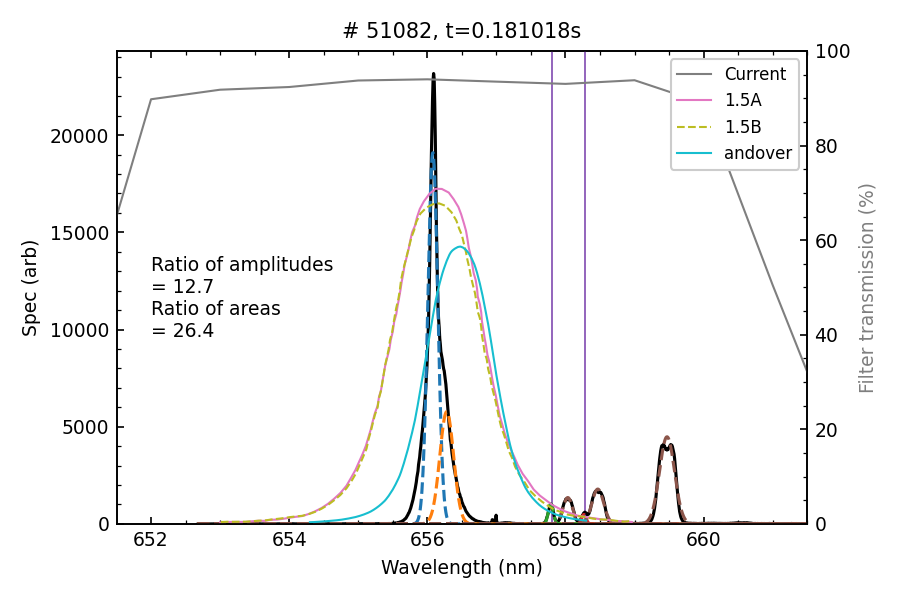

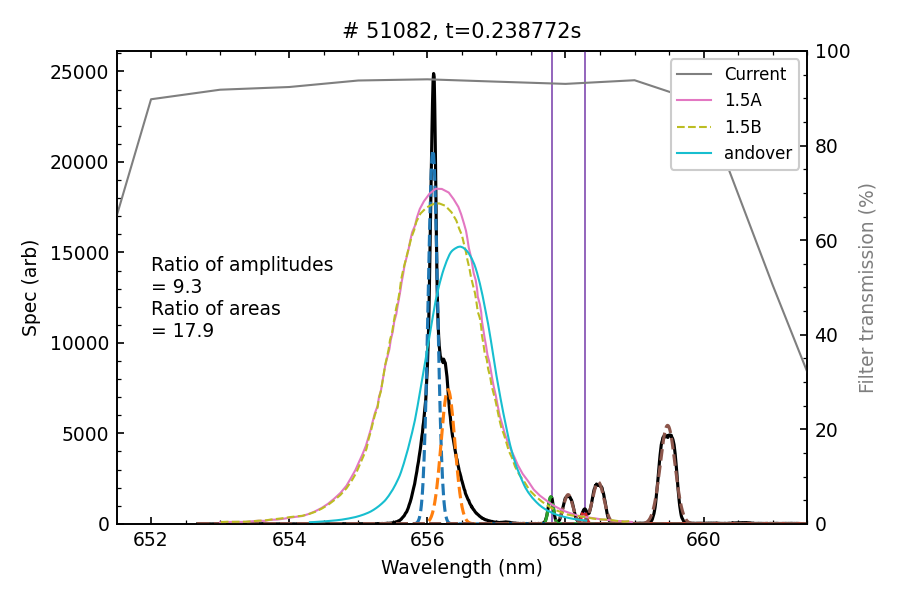

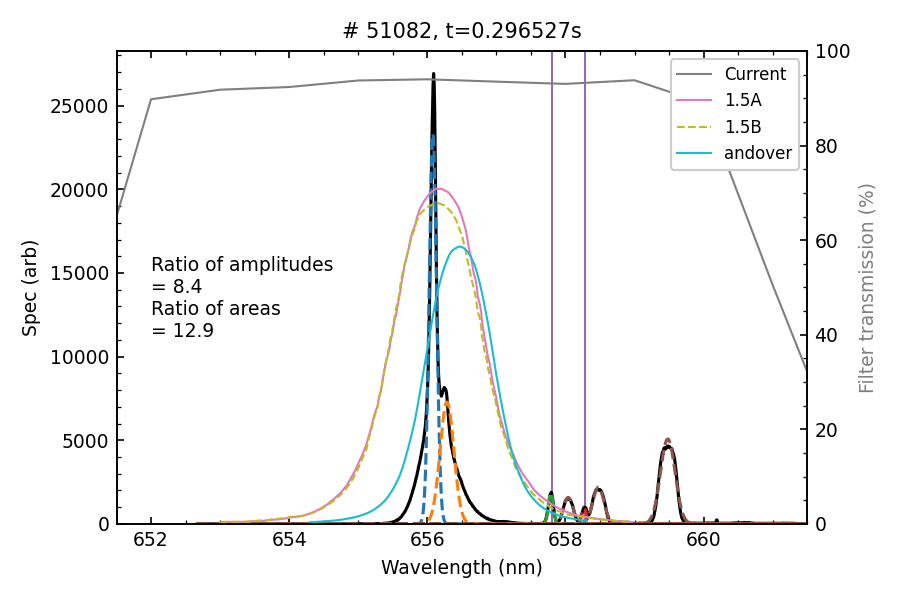

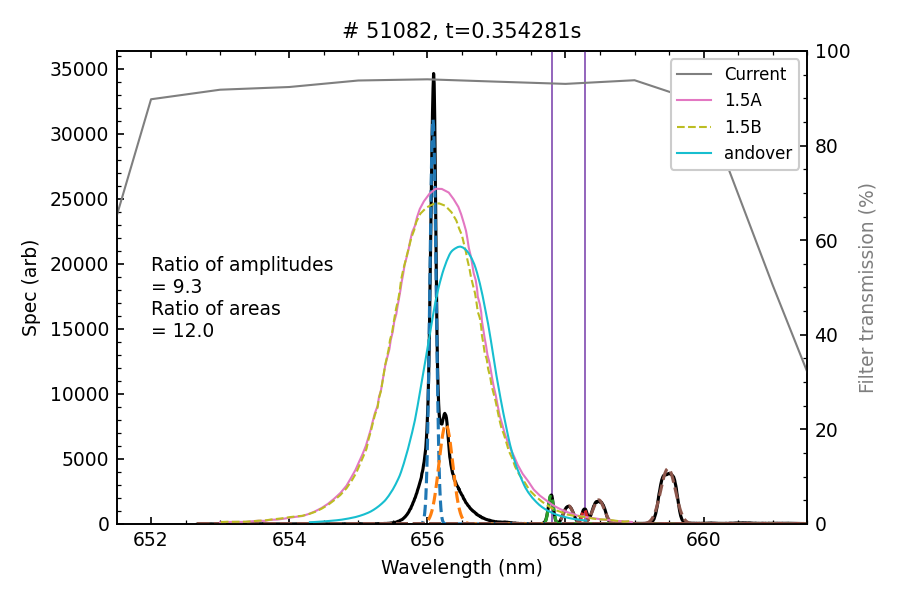

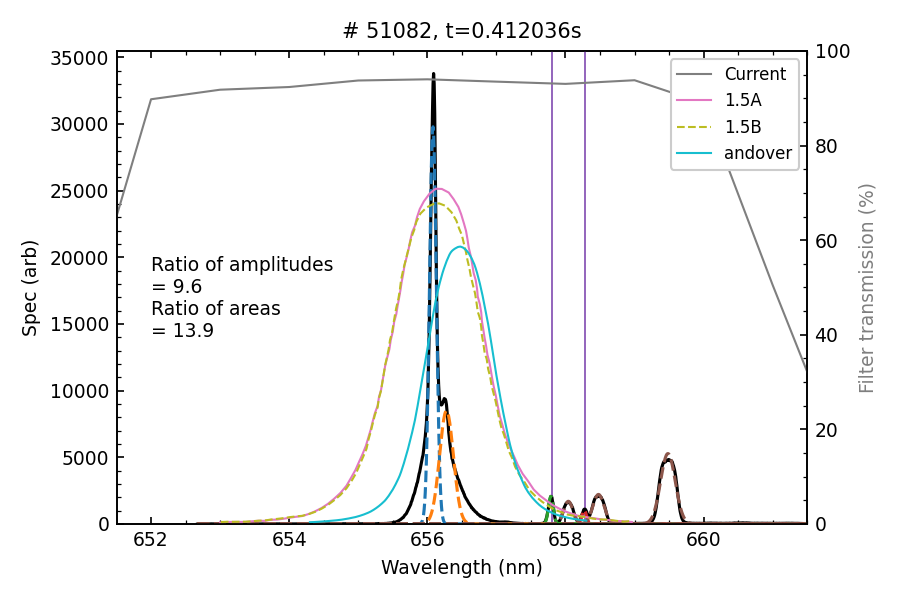

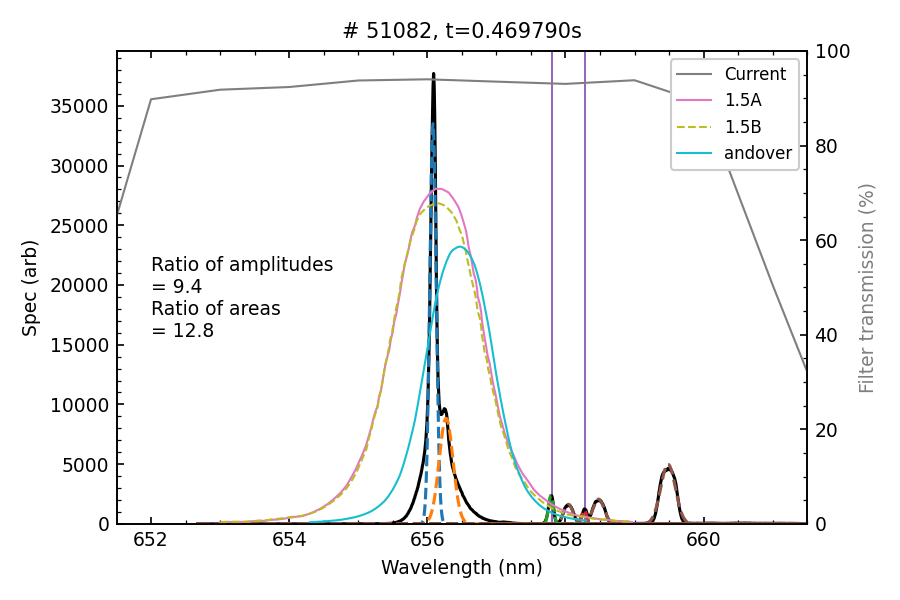

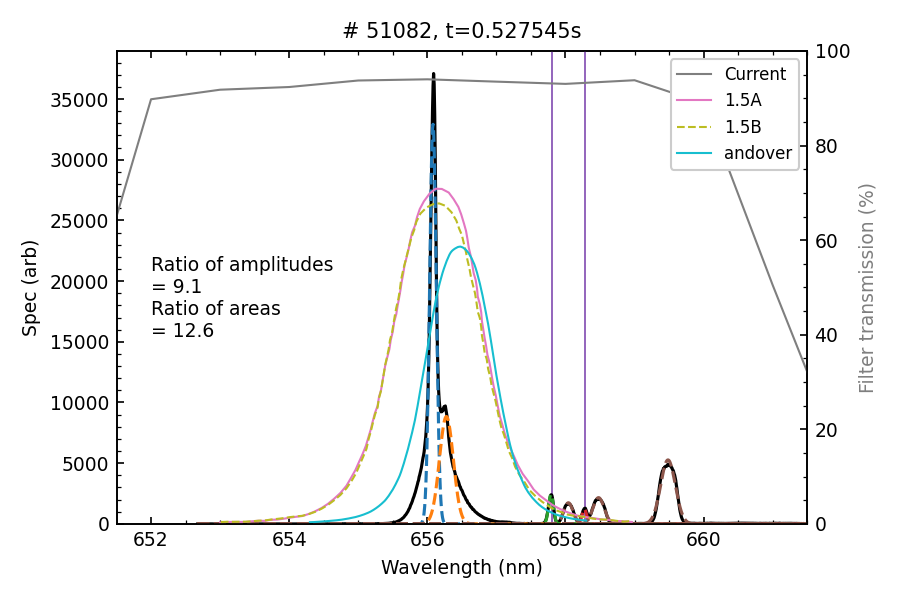

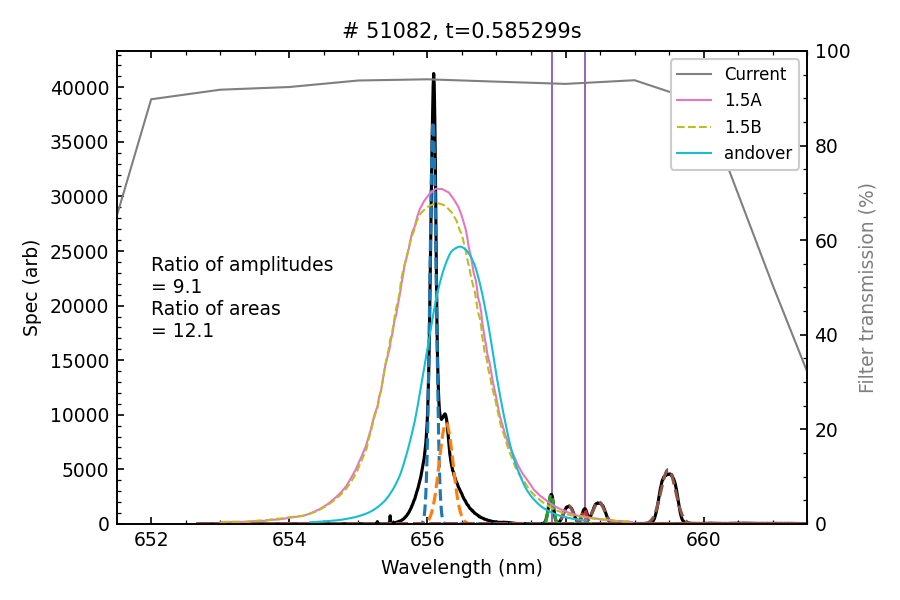

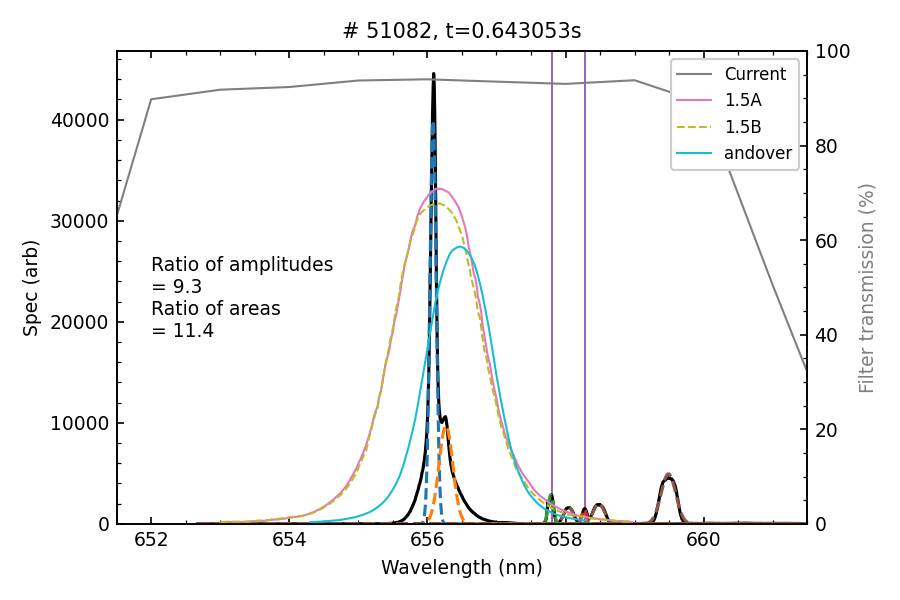

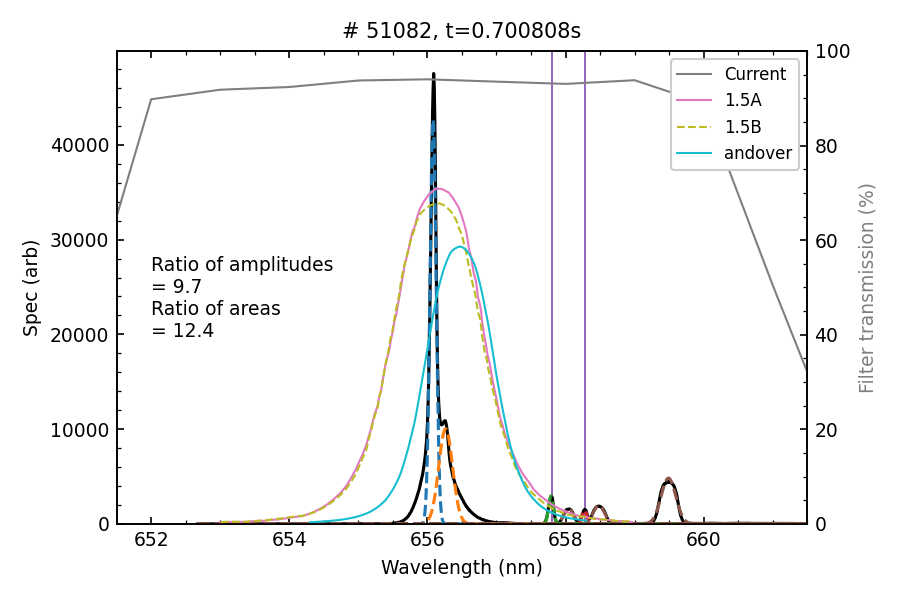

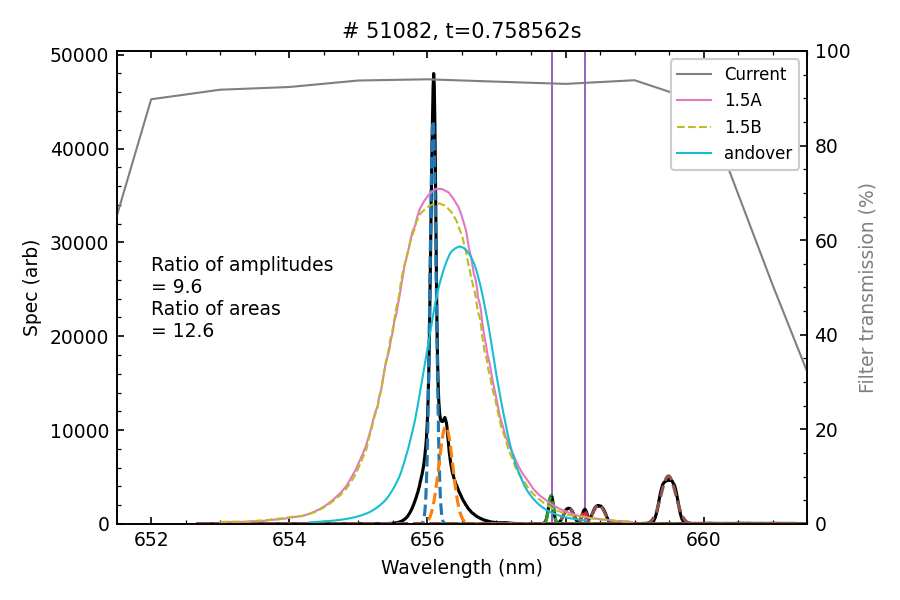

In [17]:
### select which to fit to
ch = 4 # which channel
tind0 = 4
tind1 = 15
ampRatios = np.zeros(tind1 - tind0)
areaRatios = np.zeros(tind1 - tind0)
ratio_actual = np.zeros(tind1 - tind0)
ratio_15A = np.zeros(tind1 - tind0)
ratio_15B = np.zeros(tind1 - tind0)
ratio_andover = np.zeros(tind1 - tind0)
ratio_actual2 = np.zeros(tind1 - tind0)
ratio_15A2 = np.zeros(tind1 - tind0)
ratio_15B2 = np.zeros(tind1 - tind0)
ratio_andover2 = np.zeros(tind1 - tind0)

for tind in range(tind0, tind1):
#     tind = 8 # which time
    x = wl[15:]
    y = spd[ch,tind,15:]
    y -= y[-200:].mean()

    ### fit to dalpha peaks
    I0 = findNearest(wl, 654.)
    J0 = findNearest(wl, 657.5)
    x0 = wl[I0:J0]
    y0 = spd[ch,tind,I0:J0]
    p0 = (6e5, 656.1012, 0.80, 1e5, 656.2819, 0.05)#, 600.)
    low0 = (0, 656., 0.01, 0., 656.2, 0.005)#, 0.)
    high0 = (7e5, 656.3, 8., 2e5, 656.4, .1)#, 1000.)
    popt0, pcov0 = curve_fit(func2, x0, y0, p0=p0, bounds=(low0,high0))
    pcov0 = np.sqrt(np.diag(pcov0))
    # print(popt0[0:3])
    # print(popt0[3:6])
    # print(popt0[6])
    # print(pcov0)
    p1 = (
        3000., 657.8, 0.20,     
        1600., 658.3, 0.20,     
        2000., 658.1, 0.20,     
        2000., 658.5, 0.20,     
        5000., 659.5, 0.20, 
    )
    low1 = (
        100., 657.6, 0.005,     
        100., 658.1, 0.005,     
        300., 657.9, 0.005,     
        300., 658.3, 0.005,     
        1000., 659.3, 0.005, 
    )
    high1 = (
        5000., 658.0, 0.40,     
        5000., 658.5, 0.40,     
        5000., 658.3, 0.40,     
        5000., 658.7, 0.40,     
        7000., 659.7, 0.40, 
    )

    I1 = findNearest(wl, 657.4)
    J1 = findNearest(wl, 660.5)
    x1 = wl[I1:J1]
    y1 = spd[ch,tind,I1:J1]
    
    popt1, pcov1 = curve_fit(func5, x1, y1, p0=p1, bounds=(low1,high1))
    pcov1 = np.sqrt(np.diag(pcov1))


    ### some options for plotting
    filtercolour = 'k'
    filtercolour2 = 'C7'
    filterlw = 1.
    ymin = 0.
    ymax = y0.max() * 1.05
    ymax2 = 100.
    ymin2 = ymax2/ymax*ymin
    carbonlines = [657.80481,658.2876]

    ### plot it
    fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=150)
    ax2 = ax.twinx()
    ax.vlines(carbonlines, ymin, ymax, colors='C4', linewidth=0.95, zorder=3)
    ax2.plot(filter['wavelength'], filter['transmission'], '-', c='C7', lw=filterlw, zorder=2, label='Current')
    ax2.plot(filter_15A['wavelength'], filter_15A['transmission'], '-', c='C6', lw=filterlw, zorder=2, label='1.5A')
    ax2.plot(filter_15B['wavelength'], filter_15B['transmission'], '--', c='C8', lw=filterlw, zorder=2, label='1.5B')
    ax2.plot(filter_andover['wavelength'], filter_andover['transmission'], '-', c='C9', lw=filterlw, zorder=2, label='andover')
    ax2.legend(fancybox=1, framealpha=1, loc='upper right', fontsize=8)

    ax.plot(x, y, '-k', zorder=3) # data
    ### plot the fits indivudually
    ax.plot(x, gaussian(x, popt0[0],popt0[1],popt0[2]), '--', c='C0', zorder=4)
    ax.plot(x, gaussian(x, popt0[3],popt0[4],popt0[5]), '--', c='C1', zorder=4)
    ax.plot(x, gaussian(x, popt1[0],popt1[1],popt1[2]), '--', c='C2', zorder=4)
    ax.plot(x, gaussian(x, popt1[3],popt1[4],popt1[5]), '--', c='C3', zorder=4)
    ax.plot(x, gaussian(x, popt1[6],popt1[7],popt1[8]), '--', c='C5', zorder=4)
    ax.plot(x, gaussian(x, popt1[9],popt1[10],popt1[11]), '--', c='C5', zorder=4)
    ax.plot(x, gaussian(x, popt1[12],popt1[13],popt1[14]), '--', c='C5', zorder=4)
    # ax.plot(x, gaussian(x, popt1[6],popt1[7],popt1[8])+popt1[-1], '--', c='C4', zorder=4)
    # ax.plot(x, gaussian(x, popt1[9],popt1[10],popt1[11])+popt1[-1], '--', c='C5', zorder=4)
    ### labels and title
    ax.set_xlabel('Wavelength (nm)', fontsize=9)
    ax.set_ylabel('Spec (arb)', fontsize=9)
    ax2.set_ylabel('Filter transmission (%)', c=filtercolour2, fontsize=9)
    ax.set_title('# {}, t={:.6f}s'.format(shotn,spt[tind]), fontsize=10)
    ### set the limits
    # ax.set_xlim(xlim)
    # ax.set_xticks(xticks)
    ax.set_ylim([ymin, ymax])
    ax2.set_ylim([ymin2,ymax2])
    ### tighten it up and save it
    ax.tick_params(
                    axis="both", which='both', labelsize=9, direction='in', 
                    left=True, bottom=True, right=False, top=True
                )
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax2.tick_params(
                    axis="both", which='both', labelsize=9, direction='in', 
                    left=False, bottom=False, right=True, top=False
                )
    ax2.yaxis.set_minor_locator(AutoMinorLocator())
    ax.set_xlim([651.5,661.5])

    # ampRatio = popt0[0] / (popt1[0] + popt1[6])
    # areaRatio = (popt0[0] * popt0[2]) / ((popt1[0] * popt1[2]) + (popt1[6] * popt1[8]))
    ampRatio = popt0[0] / (popt1[0] + popt1[3])
    ampRatios[tind-tind0] = ampRatio
    areaRatio = (popt0[0] * popt0[2]) / ((popt1[0] * popt1[2]) + (popt1[3] * popt1[5]))
    areaRatios[tind-tind0] = areaRatio

    ax.text(652., y.max()*0.5, 
            f'Ratio of amplitudes\n= {ampRatio:.1f}\nRatio of areas\n= {areaRatio:.1f}', 
            fontsize=9, ha='left', va='center')

    plt.tight_layout()
    plt.savefig(f'{shotn}/{shotn}_{spt[tind]:.6f}s.png')
    
    ###################################################################################
    
    Dalpha_actual = popt0[0] / (fHSV(popt0[1]) / 100.)
    C1_actual = popt1[0] / (fHSV(popt1[1]) / 100.)
    C2_actual = popt1[3] / (fHSV(popt1[4]) / 100.)
    ratio_actual[tind-tind0] = Dalpha_actual / (C1_actual + C2_actual)
    
    Dalpha_15A = Dalpha_actual * (f_15A(popt0[1]) / 100.)
    C1_15A = C1_actual * (f_15A(popt1[1]) / 100.)
    C2_15A = C2_actual * (f_15A(popt1[1+3]) / 100.)
    ratio_15A[tind-tind0] = Dalpha_15A / (C1_15A + C2_15A)
    
    Dalpha_15B = Dalpha_actual * (f_15B(popt0[1]) / 100.)
    C1_15B = C1_actual * (f_15B(popt1[1]) / 100.)
    C2_15B = C2_actual * (f_15B(popt1[1+3]) / 100.)
    ratio_15B[tind-tind0] = Dalpha_15B / (C1_15B + C2_15B)
    
    Dalpha_andover = Dalpha_actual * (f_andover(popt0[1]) / 100.)
    C1_andover = C1_actual * (f_andover(popt1[1]) / 100.)
    C2_andover = C2_actual * (f_andover(popt1[1+3]) / 100.)
    ratio_andover[tind-tind0] = Dalpha_andover / (C1_andover + C2_andover)
    
    Dalpha_actual2 = popt0[0] / (93.19368714285714 / 100.)
    C1_actual2 = popt1[0] / (93.19368714285714 / 100.)
    C2_actual2 = popt1[3] / (93.19368714285714 / 100.)
    ratio_actual2[tind-tind0] = Dalpha_actual2 / (C1_actual2 + C2_actual2)
    
    Dalpha_15A2 = Dalpha_actual2 * (f_15A(popt0[1]) / 100.)
    C1_15A2 = C1_actual2 * (f_15A(popt1[1]) / 100.)
    C2_15A2 = C2_actual2 * (f_15A(popt1[1+3]) / 100.)
    ratio_15A2[tind-tind0] = Dalpha_15A2 / (C1_15A2 + C2_15A2)
    
    Dalpha_15B2 = Dalpha_actual2 * (f_15B(popt0[1]) / 100.)
    C1_15B2 = C1_actual2 * (f_15B(popt1[1]) / 100.)
    C2_15B2 = C2_actual2 * (f_15B(popt1[1+3]) / 100.)
    ratio_15B2[tind-tind0] = Dalpha_15B2 / (C1_15B2 + C2_15B2)
    
    Dalpha_andover2 = Dalpha_actual2 * (f_andover(popt0[1]) / 100.)
    C1_andover2 = C1_actual2 * (f_andover(popt1[1]) / 100.)
    C2_andover2 = C2_actual2 * (f_andover(popt1[1+3]) / 100.)
    ratio_andover2[tind-tind0] = Dalpha_andover2 / (C1_andover2 + C2_andover2)

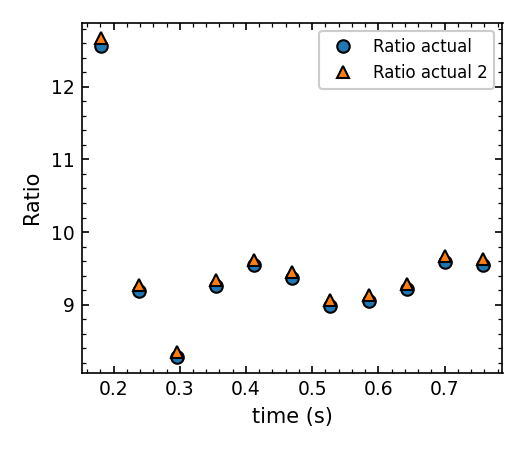

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(spt[tind0:tind1], ratio_actual, 'o', c='C0', mec='k', label='Ratio actual')
ax.plot(spt[tind0:tind1], ratio_actual2, '^', c='C1', mec='k', label='Ratio actual 2')
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlabel('time (s)')
ax.set_ylabel('Ratio')
plt.tight_layout()

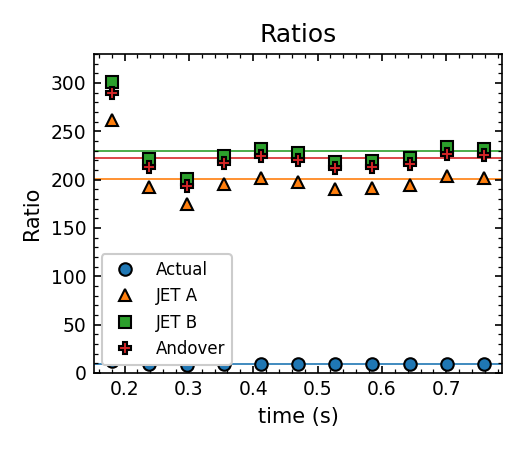

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(spt[tind0:tind1], ratio_actual, 'o', c='C0', mec='k', label='Actual', zorder=2)
ax.plot(spt[tind0:tind1], ratio_15A, '^', c='C1', mec='k', label='JET A', zorder=2)
ax.plot(spt[tind0:tind1], ratio_15B, 's', c='C2', mec='k', label='JET B', zorder=2)
ax.plot(spt[tind0:tind1], ratio_andover, 'P', c='C3', mec='k', label='Andover', zorder=2)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlabel('time (s)')
ax.set_ylabel('Ratio')
ax.set_title('Ratios')
xlim = ax.get_xlim()
ax.set_xlim(xlim)
ax.set_ylim([0,330])
ax.plot(xlim, [ratio_actual.mean(),ratio_actual.mean()], '-', c='C0', lw=0.8, zorder=1)
ax.plot(xlim, [ratio_15A.mean(),ratio_15A.mean()], '-', c='C1', lw=0.8, zorder=1)
ax.plot(xlim, [ratio_15B.mean(),ratio_15B.mean()], '-', c='C2', lw=0.8, zorder=1)
ax.plot(xlim, [ratio_andover.mean(),ratio_andover.mean()], '-', c='C3', lw=0.8, zorder=1)
plt.tight_layout()

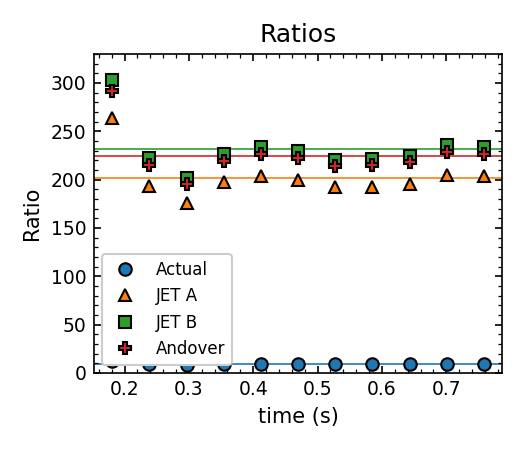

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(spt[tind0:tind1], ratio_actual2, 'o', c='C0', mec='k', label='Actual')
ax.plot(spt[tind0:tind1], ratio_15A2, '^', c='C1', mec='k', label='JET A')
ax.plot(spt[tind0:tind1], ratio_15B2, 's', c='C2', mec='k', label='JET B')
ax.plot(spt[tind0:tind1], ratio_andover2, 'P', c='C3', mec='k', label='Andover')
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlabel('time (s)')
ax.set_ylabel('Ratio')
ax.set_title('Ratios')
xlim = ax.get_xlim()
ax.set_xlim(xlim)
ax.set_ylim([0,330])
ax.plot(xlim, [ratio_actual2.mean(),ratio_actual2.mean()], '-', c='C0', lw=0.8, zorder=1)
ax.plot(xlim, [ratio_15A2.mean(),ratio_15A2.mean()], '-', c='C1', lw=0.8, zorder=1)
ax.plot(xlim, [ratio_15B2.mean(),ratio_15B2.mean()], '-', c='C2', lw=0.8, zorder=1)
ax.plot(xlim, [ratio_andover2.mean(),ratio_andover2.mean()], '-', c='C3', lw=0.8, zorder=1)
plt.tight_layout()

In [ ]:
# ampRatios = np.zeros(tind1 - tind0)
# areaRatios = np.zeros(tind1 - tind0)
# ratio_actual = np.zeros(tind1 - tind0)
# ratio_15A = np.zeros(tind1 - tind0)
# ratio_15B = np.zeros(tind1 - tind0)
# ratio_andover = np.zeros(tind1 - tind0)
# ratio_actual2 = np.zeros(tind1 - tind0)
# ratio_15A2 = np.zeros(tind1 - tind0)
# ratio_15B2 = np.zeros(tind1 - tind0)
# ratio_andover2 = np.zeros(tind1 - tind0)

In [59]:
from mastu import HSV
timePed, dataDensity, _, Rthomson = HSV.getThomson(49091, 'n_e')
_, dataTemp, _, _ = HSV.getThomson(49091, 'T_e')



In [72]:
for i in range(0, dataDensity.shape[0]):
    boo1 = np.isfinite(dataDensity[i])
    boo2 = np.isfinite(dataTemp[i])
    boo3 = boo1 * boo2
    print((boo1 == boo2).all(), (boo1 == boo3).all(), (boo2 == boo3).all())

True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True 

In [70]:
dataDensity[79], dataTemp[79]

(array([4.62279962e+19, 2.82196353e+19, 2.76566879e+19, 2.98385413e+19,
        3.01791702e+19, 3.07088000e+19, 3.07878614e+19, 3.24259478e+19,
        3.74337080e+19, 3.45896016e+19, 3.88272568e+19,            nan,
        3.65458515e+19, 3.84719834e+19, 3.94286986e+19, 4.13605367e+19,
        4.45541533e+19, 4.27962148e+19, 4.58412645e+19, 4.34932780e+19,
        5.33477346e+19, 4.68364121e+19, 4.53095145e+19, 4.90754322e+19,
        4.31184022e+19, 4.45299122e+19, 4.38399233e+19, 4.45890507e+19,
        4.58146067e+19, 4.73866805e+19, 4.67884213e+19, 4.82211874e+19,
        4.94047250e+19, 4.29981364e+19, 4.52292697e+19, 4.49226609e+19,
        4.68100184e+19, 4.50208908e+19, 4.37652997e+19, 4.61293109e+19,
        4.60770249e+19, 4.60908035e+19, 4.79273063e+19, 4.50608929e+19,
        4.77975605e+19, 4.74853795e+19, 4.63373013e+19, 4.82391371e+19,
        4.69029364e+19, 4.50423200e+19, 4.50393313e+19, 4.57599476e+19,
        4.61467663e+19, 4.35708858e+19, 4.43389819e+19, 4.367814

In [61]:
functions.findNearest(Rthomson[79], 1.)

84

In [65]:
timePed[79]

0.500103

In [63]:
Rthomson[79,84:]

array([0.99819976, 1.00843489, 1.01875031, 1.02914762, 1.03962803,
       1.05019224, 1.06084085, 1.07157373, 1.08239043, 1.09329021,
       1.10427153, 1.11533248, 1.12647069, 1.13768315, 1.14896643,
       1.16031623, 1.17172778, 1.18319571, 1.19471395, 1.20627594,
       1.21787393, 1.22949994, 1.24114513, 1.25279963, 1.26445305,
       1.27609432, 1.28771102, 1.2992903 , 1.31081843, 1.32228065,
       1.3336612 , 1.34494364, 1.35611033, 1.36714292, 1.37802172,
       1.38872612, 1.39919078, 1.40943837, 1.41944563, 1.42918777,
       1.43863893, 1.44777226, 1.45655978, 1.46497202, 1.47297871,
       1.48054802])

In [62]:
dataTemp[79,84:]

array([820.4133992 , 841.39486548, 809.57366792, 779.16438553,
       738.5447457 , 822.44602826, 773.45072985, 877.1084329 ,
       870.0195933 , 812.16713657, 791.99477458, 816.9407469 ,
       841.22764677, 804.99561144, 812.30018134, 759.60431719,
       740.32633105, 673.59106706, 580.35552959, 584.84174366,
       551.51416885, 482.45167131, 432.59547537, 386.90103912,
       357.75790945, 374.33229325, 358.4744269 , 323.9981874 ,
       311.20338012, 299.0870004 , 303.12099891, 293.95193074,
       274.90232872, 277.04677976, 214.62291577,  24.84310918,
         9.18722196,  10.72561989,          inf,          inf,
                inf,          inf,          inf,          inf,
                inf,          inf])

In [27]:
Rthomson[10]

array([0.30636001, 0.30573225, 0.30571657, 0.30629399, 0.30744535,
       0.30915126, 0.31139231, 0.3141489 , 0.31740147, 0.32113039,
       0.32531607, 0.32993898, 0.33497965, 0.34041876, 0.34623709,
       0.35243669, 0.35897931, 0.36584592, 0.37301812, 0.38047788,
       0.38820735, 0.39618912, 0.4044061 , 0.41284159, 0.42147925,
       0.43030319, 0.43929791, 0.44844845, 0.45774022, 0.46715915,
       0.47669169, 0.48632476, 0.49604586, 0.50584292, 0.51570445,
       0.52561963, 0.53557801, 0.54556984, 0.55558586, 0.56561744,
       0.57565653, 0.58569556, 0.59572768, 0.60574657, 0.61574638,
       0.62572211, 0.63566899, 0.64558321, 0.65522194, 0.66486031,
       0.67446476, 0.68403554, 0.69357324, 0.70307893, 0.71255386,
       0.72199982, 0.73141897, 0.74081349, 0.75018609, 0.75953972,
       0.76887745, 0.77820265, 0.78751892, 0.79682994, 0.80613965,
       0.81545204, 0.82477123, 0.8341015 , 0.84344709, 0.85281235,
       0.86220163, 0.8716194 , 0.8810699 , 0.89055753, 0.90008

In [28]:
import functions

In [40]:
functions.loadADAS()[1]

array([5.e+13, 1.e+14, 2.e+14, 5.e+14, 1.e+15, 2.e+15, 5.e+15, 1.e+16,
       2.e+16, 5.e+16, 1.e+17, 2.e+17, 5.e+17, 1.e+18, 2.e+18, 5.e+18,
       1.e+19, 2.e+19, 5.e+19, 1.e+20, 2.e+20, 5.e+20, 1.e+21, 2.e+21])

In [ ]:
filter['wavelength'][22:29]

In [33]:
filter['transmission'][22:29].mean()

93.19368714285714

In [48]:
ratio_15A, ratio_15A2, 0.5 * (ratio_15A + ratio_15A2)

(286.7072073321638, 289.2014544791939, 287.95433090567883)

In [49]:
ratio_15B, ratio_15B2, 0.5 * (ratio_15B + ratio_15B2)

(329.0583107750586, 331.91103848713163, 330.4846746310951)

In [50]:
ratio_andover, ratio_andover2, 0.5 * (ratio_andover + ratio_andover2)

(320.74224833293437, 323.5418683889233, 322.14205836092884)

In [66]:
data = np.load('/home/sthoma/Documents/Results/rba/49091/rba_results.npz')
data2 = np.load('/home/sthoma/Documents/Results/rba/49091/rba_results_4.npz')
for k in data.keys():
    print(k, np.isclose(data[k], data2[k]).all(), np.isclose(data2[k], data[k]).all())

R True True
data True True
err True True
time True True
Rgrid True True
RgridB True True
emissivity True True
emissivityErr True True
backprojection True True
scale True True
emMax True True
emMaxR True True
emR0 True True
emR1 True True
emFWHM True True
emFWHMerr True True
Rind True True
Rprofile True True
profileTemp False False
profileDensity False False
ioniseRate False False
ioniseErr False False
neutralDensity False False
neutralErr False False
ioniseMax False False
ioniseMaxR True True
ioniseR0 False False
ioniseR1 False False
ioniseFWHM False False
ioniseFWHMerr False False
neutralMax False False
neutralMaxR False False
neutralR1 False False
neutralR2 False False
neutralR3 False False
neutralWidth1 False False
neutralWidth1err False False
neutralWidth2 False False
neutralWidth2err False False
neutralWidth3 False False
neutralWidth3err False False
neutralR1A False False
neutralR2A False False
neutralR3A False False
neutralWidth1A False False
neutralWidth1Aerr False False
neutral

In [45]:
data = np.load('/home/sthoma/Documents/Results/rba/49091/rba_results.npz')
data2 = np.load('/home/sthoma/Documents/Results/rba/49091/rba_results_2.npz')
for k in data.keys():
    print(k, np.isclose(data[k], data2[k]).all(), np.isclose(data2[k], data[k]).all())

R True True
data True True
err True True
time True True
Rgrid True True
RgridB True True
emissivity True True
emissivityErr True True
backprojection True True
scale True True
emMax True True
emMaxR True True
emR0 True True
emR1 True True
emFWHM True True
emFWHMerr True True
Rind True True
Rprofile True True
profileTemp False False
profileDensity False False
ioniseRate False False
ioniseErr False False
neutralDensity False False
neutralErr False False
ioniseMax False False
ioniseMaxR False False
ioniseR0 False False
ioniseR1 False False
ioniseFWHM False False
ioniseFWHMerr False False
neutralMax False False
neutralMaxR False False
neutralR1 False False
neutralR2 False False
neutralR3 False False
neutralWidth1 False False
neutralWidth1err False False
neutralWidth2 False False
neutralWidth2err False False
neutralWidth3 False False
neutralWidth3err False False
neutralR1A False False
neutralR2A False False
neutralR3A False False
neutralWidth1A False False
neutralWidth1Aerr False False
neutr

In [67]:
data2['profileDensity']

array([[4.14423064e+19, 4.14342936e+19, 4.15500968e+19, 4.16999136e+19,
        4.18497304e+19, 4.19272901e+19, 4.18823448e+19, 4.18373995e+19,
        4.17924542e+19, 4.29686915e+19, 4.41943909e+19, 4.54200903e+19,
        4.62729752e+19, 4.68309526e+19, 4.73889301e+19, 4.76612099e+19,
        4.65039780e+19, 4.53467462e+19, 4.41895143e+19, 4.34732765e+19,
        4.28744228e+19, 4.22755692e+19, 4.19645827e+19, 4.20316326e+19,
        4.20986825e+19, 4.22999195e+19, 4.37260483e+19, 4.51521771e+19,
        4.65783060e+19, 4.49835947e+19, 4.26047083e+19, 4.02258220e+19,
        4.00321815e+19, 4.18316478e+19, 4.36311142e+19, 4.41894030e+19,
        4.17288877e+19, 3.92683725e+19, 3.61973458e+19, 2.79095410e+19,
        1.96217362e+19, 1.13339314e+19, 8.66510769e+18, 6.17446835e+18,
        3.68382900e+18, 3.21615074e+18, 2.96334859e+18, 2.71054644e+18,
        5.00000100e+13, 5.00000100e+13, 5.00000100e+13, 5.00000100e+13,
        5.00000100e+13, 5.00000100e+13, 5.00000100e+13, 5.000001

In [58]:
(np.isfinite(data2['profileDensity']) == ~np.isnan(data2['profileDensity'])).all()

True

In [54]:
(np.isfinite(data2['profileTemp']) == ~np.isinf(data2['profileTemp'])).all()

True

In [68]:
data2['profileTemp']

array([[4.03170855e+02, 3.89785660e+02, 3.80203336e+02, 3.71665702e+02,
        3.63128068e+02, 3.59561209e+02, 3.64421834e+02, 3.69282460e+02,
        3.74143085e+02, 3.69853376e+02, 3.65193046e+02, 3.60532717e+02,
        3.52799104e+02, 3.42634431e+02, 3.32469759e+02, 3.23367057e+02,
        3.19578013e+02, 3.15788970e+02, 3.11999926e+02, 3.08353258e+02,
        3.04744487e+02, 3.01135716e+02, 2.99610129e+02, 3.00820245e+02,
        3.02030362e+02, 3.02847067e+02, 3.00072617e+02, 2.97298167e+02,
        2.94523717e+02, 2.89328252e+02, 2.83504321e+02, 2.77680390e+02,
        2.75249376e+02, 2.75912957e+02, 2.76576538e+02, 2.71339217e+02,
        2.51749666e+02, 2.32160115e+02, 2.08281739e+02, 1.47755648e+02,
        8.72295578e+01, 2.67034673e+01, 1.98926103e+01, 1.47851253e+01,
        9.67764034e+00, 9.65052051e+00, 1.01630300e+01, 1.06755395e+01,
        2.00001000e-01, 2.00001000e-01, 2.00001000e-01, 2.00001000e-01,
        2.00001000e-01, 2.00001000e-01, 2.00001000e-01, 2.000010